In [1]:
import numpy
import sys
import os
import matplotlib.pyplot as plt
import scipy
import mantid
from mantid.simpleapi import *
import scippneutron
import h5py
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import ipyvolume as ipv


FrameworkManager-[Notice] Welcome to Mantid 6.13.1
FrameworkManager-[Notice] Please cite: http://dx.doi.org/10.1016/j.nima.2014.07.029 and this release: http://dx.doi.org/10.5286/Software/Mantid6.13.1
CheckMantidVersion-[Notice] A new version of Mantid(6.15.0) is available for download from https://download.mantidproject.org
DownloadInstrument-[Notice] All instrument definitions up to date


In [11]:
f_nexus = "magic_C60_zeros.h5"
f_nexus = r'/Users/iuriikibalin/Documents/files/ESS/McStas/mcstasscript_magic/run_folder_35/mccode.h5'
print(os.path.isfile(f_nexus))

True


In [12]:
Load(f_nexus, OutputWorkspace='mcstas_data')

Load-[Notice] Load started
InstrumentDefinitionParser-[Notice] Geometry cache is not available
InstrumentDefinitionParser-[Notice] Creating cache in /Users/iuriikibalin/.mantid/instrument/geometryCache/McStasdeb3358575a2bf03922a9da3446a652e308891cf.vtp
Load-[Notice] Load successful, Duration 1.64 seconds


WorkspaceGroup
 -- EventData_mcstas_data
 -- divpos_sample_pos_1.plot_mcstas_data
 -- psd_sample_pos_1.plot_mcstas_data
 -- tof_chop_1.plot_mcstas_data
 -- tof_egs2_1.plot_mcstas_data
 -- tof_w6_1.plot_mcstas_data

In [13]:
print(mtd.getObjectNames())

['divpos_sample_pos_1.plot_mcstas_data', 'EventData_mcstas_data', 'l_monitor_sample.txt_mcstas_data', 'mcstas_data', 'psd_sample_pos_1.plot_mcstas_data', 'tof_chop_1.plot_mcstas_data', 'tof_egs2_1.plot_mcstas_data', 'tof_w6_1.plot_mcstas_data']


In [28]:
from mantid.simpleapi import CreateWorkspace
ws = mtd['tof_egs2_1.plot_mcstas_data']

monitor = ws.readY(0)
mon_ws = CreateWorkspace(
    DataX=ws.readX(0),
    DataY=monitor,
    NSpec=1,
    UnitX=ws.getAxis(0).getUnit().unitID()
)

from mantid.simpleapi import Divide


CreateWorkspace-[Notice] CreateWorkspace started
CreateWorkspace-[Notice] CreateWorkspace successful, Duration 0.01 seconds


In [29]:
mtd['EventData_mcstas_data']

EventWorkspace
Title: 
Histograms: 64128
Bins: 1
Histogram
X axis: Time-of-flight / microsecond
Y axis: Counts
Distribution: False
Instrument: McStas (1900-Jan-31 to 2100-Jan-31)Instrument from: /Users/iuriikibalin/Documents/files/ESS/McStas/mcstasscript_magic/run_folder_35/mccode.h5

Run start: not available
Run end:  not available

Events: 16310401 (weighted)

In [30]:
mtd['EventData_mcstas_data']

EventWorkspace
Title: 
Histograms: 64128
Bins: 1
Histogram
X axis: Time-of-flight / microsecond
Y axis: Counts
Distribution: False
Instrument: McStas (1900-Jan-31 to 2100-Jan-31)Instrument from: /Users/iuriikibalin/Documents/files/ESS/McStas/mcstasscript_magic/run_folder_35/mccode.h5

Run start: not available
Run end:  not available

Events: 16310401 (weighted)

In [31]:
mtd['EventData_mcstas_data'].getNumberHistograms()

64128

In [32]:
mtd['EventData_mcstas_data'].getNumberEvents()

16310401

In [33]:
from mantid.simpleapi import Rebin

# Convert to MD and visualize in Q‑space (if needed)


In [38]:
from mantid.simpleapi import ConvertToMD

ConvertToDiffractionMDWorkspace(InputWorkspace='EventData_mcstas_data', OutputWorkspace='md_space')
md = mtd['md_space']

ConvertToDiffractionMDWorkspace-[Notice] ConvertToDiffractionMDWorkspace started
ConvertToDiffractionMDWorkspace-[Notice] ConvertToDiffractionMDWorkspace successful, Duration 2.03 seconds


In [39]:
md

MDEventWorkspace<MDEvent,3>
Title: 
Dim 0: (Q_lab_x) -12.1544 to -1.9647 in 2 bins. Id=Q1
Dim 1: (Q_lab_y) -4.11854 to 6.55952 in 2 bins. Id=Q2
Dim 2: (Q_lab_z) 1.34517 to 18.2316 in 2 bins. Id=Q3

Inelastic: ki-kf
66564 MDBoxes (15340 kB)
9509 MDGridBoxes (2711 kB)
Not file backed.
Instrument: McStas (1900-Jan-31 to 2100-Jan-31)Instrument from: /Users/iuriikibalin/Documents/files/ESS/McStas/mcstasscript_magic/run_folder_35/mccode.h5

Run start: not available
Run end:  not available

Events: 16310401

In [40]:
ws = md

dims = [ws.getDimension(i) for i in range(ws.getNumDims())]
xmin, xmax = dims[0].getMinimum(), dims[0].getMaximum()
ymin, ymax = dims[1].getMinimum(), dims[1].getMaximum()
zmin, zmax = dims[2].getMinimum(), dims[2].getMaximum()

extent_x = xmax - xmin
extent_y = ymax - ymin
extent_z = zmax - zmin

# total number of events
nevents = ws.getNPoints()

## Choose an automatic binning rule

For 3D event clouds, a good rule is:
Bins per axis ≈ (N_events)^(1/3) / k
where k controls smoothness:

 - k = 3 → fine resolution
 - k = 4–5 → medium
 - k = 6–8 → coarse

This is analogous to Scott’s rule / Freedman–Diaconis but adapted to 3D.

In [41]:
k = 3  # smooth but not too coarse
nbins = int((nevents ** (1/3)) / k)

# enforce reasonable limits
nbins = max(20, min(nbins, 200))
nbins

84

In [42]:
from mantid.simpleapi import BinMD

binned = BinMD(
    InputWorkspace=ws,
    AlignedDim0=f"Q_lab_x,{xmin},{xmax},{nbins}",
    AlignedDim1=f"Q_lab_y,{ymin},{ymax},{nbins}",
    AlignedDim2=f"Q_lab_z,{zmin},{zmax},{nbins}"
)

BinMD-[Notice] BinMD started
BinMD-[Notice] BinMD successful, Duration 0.09 seconds


In [43]:

data = binned.getSignalArray()  # shape (nx, ny, nz)

dims = [binned.getDimension(i) for i in range(3)]
qx = np.linspace(dims[0].getMinimum(), dims[0].getMaximum(), dims[0].getNBins())
qy = np.linspace(dims[1].getMinimum(), dims[1].getMaximum(), dims[1].getNBins())
qz = np.linspace(dims[2].getMinimum(), dims[2].getMaximum(), dims[2].getNBins())

QX, QY, QZ = np.meshgrid(qx, qy, qz, indexing="ij")


In [44]:
import ipyvolume as ipv
import ipywidgets as widgets
import numpy as np
import matplotlib.cm as cm 
import matplotlib
import matplotlib.colors as colors

# Flatten arrays
qx = QX.flatten()
qy = QY.flatten()
qz = QZ.flatten()
val = data.flatten()

# Normalize for colormap
norm = colors.Normalize(vmin=val.min(), vmax=val.max())
cmap = matplotlib.colormaps.get_cmap("viridis")

# Initial threshold
initial_thr = np.percentile(val, 90)
mask = val > initial_thr

# Initial colors
col = cmap(norm(val[mask]))[:, :3]

# Create figure
fig = ipv.figure()
fig.camera.projection = 'orthographic'
scatter = ipv.scatter(
    qx[mask], qy[mask], qz[mask],
    color=col,
    size=3,
    marker="sphere"
)

ipv.show()

# --- Widgets ---

thr_slider = widgets.FloatSlider(
    value=initial_thr,
    min=float(val.min()),
    max=float(val.max()),
    step=(val.max() - val.min()) / 200,
    description='Threshold',
    continuous_update=False
)

proj_toggle = widgets.ToggleButton(
    value=False,
    description='Orthographic OFF',
    icon='cube'
)

# --- Callbacks ---

def update_threshold(change):
    thr = change["new"]
    mask = val > thr

    scatter.x = qx[mask]
    scatter.y = qy[mask]
    scatter.z = qz[mask]

    scatter.color = cmap(norm(val[mask]))[:, :3]

thr_slider.observe(update_threshold, names="value")

def update_projection(change):
    if change["new"]:
        fig.camera.projection = 'orthographic'
        proj_toggle.description = "Orthographic ON"
        proj_toggle.icon = "square"
    else:
        fig.camera.projection = 'perspective'
        proj_toggle.description = "Orthographic OFF"
        proj_toggle.icon = "cube"

proj_toggle.observe(update_projection, names="value")

widgets.VBox([thr_slider, proj_toggle])


Container(figure=Figure(box_center=[0.5, 0.5, 0.5], box_size=[1.0, 1.0, 1.0], camera=PerspectiveCamera(fov=45.…

# Find peaks in MD space

In [45]:
FindPeaksMD(
    InputWorkspace="md_space", 
    OutputWorkspace="strong_peaks",
    PeakDistanceThreshold='0.1',
    MaxPeaks='100')

FindPeaksMD-[Notice] FindPeaksMD started
FindPeaksMD-[Notice] Number of peaks found exceeded the limit of 100. Stopping peak finding.
FindPeaksMD-[Notice] Number of peaks found: 100
FindPeaksMD-[Notice] FindPeaksMD successful, Duration 1.09 seconds


PeaksWorkspace
Columns: 22
Rows: 100
41 kB
Instrument: McStas (1900-Jan-31 to 2100-Jan-31)Instrument from: /Users/iuriikibalin/Documents/files/ESS/McStas/mcstasscript_magic/run_folder_35/mccode.h5

Run start: not available
Run end:  not available
Inelastic: ki-kf

In [46]:
def print_table(work_space_name:str, l_name_print=[]):
    work_space = mtd[work_space_name]
    l_column_name = work_space.getColumnNames()
    n_line = work_space.rowCount()
    ls_out = []
    ls_out.append(' '.join(['{:<10}'.format(str(hh)) for hh in l_column_name  if not(len(l_name_print)!=0 and not(hh in l_name_print)) ]))
    for i in range(n_line):
        l_hh = []
        for name in l_column_name:
            if len(l_name_print)!=0 and not(name in l_name_print):
                continue
            val = work_space.column(name)[i]
            if isinstance(val, float):
                sval = f"{val:10.3f}"
            elif isinstance(val, int):
                sval = f"{val:10}"
            else:
                sval = '{:<10}'.format(str(val))
            l_hh.append(sval)
        ls_out.append(' '.join(l_hh))
    return '\n'.join(ls_out)

In [47]:
print(print_table("strong_peaks",l_name_print=['QLab', 'Wavelength']))

Wavelength QLab      
     1.302 [-4.62115,0.724296,3.63919]
     1.465 [-3.82083,-0.755435,2.49181]
     2.045 [-3.03622,0.199858,2.64957]
     2.037 [-3.01245,0.624948,2.86921]
     2.064 [-2.51977,1.17776,1.80668]
     1.449 [-3.98036,1.06821,2.9875]
     1.521 [-3.54294,1.93371,3.25261]
     1.572 [-3.56231,1.54634,3.05062]
     1.480 [-3.29138,2.207,2.72202]
     1.581 [-3.83055,0.863608,3.36659]
     1.507 [-3.91011,-1.21611,3.38165]
     1.745 [-3.5223,-0.741487,3.48336]
     1.885 [-3.27527,-0.486001,2.95379]
     1.413 [-4.2272,-0.0252158,3.06456]
     1.354 [-3.92001,2.24707,3.58169]
     1.522 [-4.07894,0.588121,3.88859]
     1.508 [-3.80053,1.66303,3.77547]
     1.254 [-4.11057,2.05923,3.02145]
     1.597 [-3.91,-0.422559,3.82772]
     1.431 [-4.22814,0.791665,3.51053]
     1.920 [-3.2703,-0.0700756,3.16989]
     1.395 [-3.94985,1.85179,3.38337]
     1.877 [-3.25088,0.751874,3.60603]
     1.610 [-3.90023,-0.0221256,4.04169]
     1.639 [-3.74076,0.189365,4.65392]
     1.743 

In [48]:
np_qlab = numpy.array(mtd["strong_peaks"].column('QLab'), dtype=float).transpose()


Text(0.5, 1.0, 'Found peaks in Q-space')

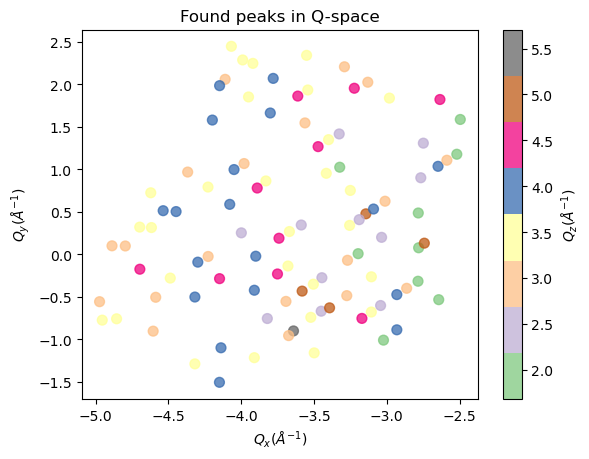

In [49]:
plt.scatter(np_qlab[0], np_qlab[1], c=np_qlab[2], alpha=0.75, s=50, cmap='Accent')
cbar = plt.colorbar()
cbar.set_label(r'$Q_z  (\AA^{-1})$')
plt.xlabel(r'$Q_x (\AA^{-1})$')
plt.ylabel(r'$Q_y (\AA^{-1})$')
plt.title('Found peaks in Q-space')

Text(0.5, 1.0, 'Found peaks in Q-space')

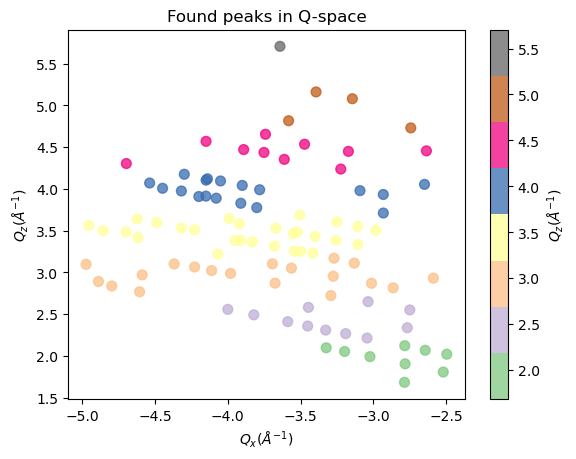

In [50]:
plt.scatter(np_qlab[0], np_qlab[2], c=np_qlab[2], alpha=0.75, s=50, cmap='Accent')
cbar = plt.colorbar()
cbar.set_label(r'$Q_z  (\AA^{-1})$')
plt.xlabel(r'$Q_x (\AA^{-1})$')
plt.ylabel(r'$Q_z (\AA^{-1})$')
plt.title('Found peaks in Q-space')

In [51]:
a, b, c = 14.04078, 14.04078, 14.04078
alpha, beta, gamma = 90, 90, 90
cell_type = 'Cubic'
centering = 'P'

CreateSingleValuedWorkspace(OutputWorkspace='sample')
SetUB(Workspace='sample', a=a, b=b, c=c, alpha=alpha, beta=beta, gamma=gamma)

CreateSingleValuedWorkspace-[Notice] CreateSingleValuedWorkspace started
CreateSingleValuedWorkspace-[Notice] CreateSingleValuedWorkspace successful, Duration 0.00 seconds
SetUB-[Notice] SetUB started
SetUB-[Notice] SetUB successful, Duration 0.00 seconds


# Searching UB-matrix

In [52]:
tol = 0.3
FindUBUsingLatticeParameters(PeaksWorkspace="strong_peaks", a=a,b=b,c=c,alpha=alpha,beta=beta, gamma=gamma,Tolerance=tol)

FindUBUsingLatticeParameters-[Notice] FindUBUsingLatticeParameters started
FindUBUsingLatticeParameters-[Notice] Error = 1.31961
FindUBUsingLatticeParameters-[Notice] UB = Matrix(3,3)0.000762198,-0.0252459,-0.0656547,0.063993,0.0318018,-0.0119948,0.0343804,-0.0609176,0.0237059
FindUBUsingLatticeParameters-[Notice] New UB will index 100 Peaks out of 100 with tolerance 0.300
FindUBUsingLatticeParameters-[Notice] Lattice Parameters:   13.766555   13.668058   14.126444   88.142099   89.943525   89.152679  2656.372821
FindUBUsingLatticeParameters-[Notice] Parameter Errors  :    0.039063    0.053552    0.026163    0.245932    0.194198    0.277234   13.766418
FindUBUsingLatticeParameters-[Notice] Lattice Parameters (Refined - Input):   -0.274225   -0.372722    0.085664   -1.857901   -0.056475   -0.847321
FindUBUsingLatticeParameters-[Notice] FindUBUsingLatticeParameters successful, Duration 0.21 seconds


In [53]:
IndexPeaks(PeaksWorkspace="strong_peaks")


IndexPeaks-[Notice] IndexPeaks started
IndexPeaks-[Warning] Peaks from only one run exist but CommonUBForAll=True so peaks will be indexed with an optimised UB which will not be saved in the workspace.
IndexPeaks-[Notice] Run 0 indexed 95 peaks out of 100 with tolerance of 0.15
IndexPeaks-[Notice]   Average error in h,k,l for indexed peaks =  0.0321144
IndexPeaks-[Notice] All runs indexed 95 peaks out of 100 with tolerance of 0.15
IndexPeaks-[Notice]   Average error in h,k,l for indexed peaks =  0.0321144
IndexPeaks-[Notice] Lattice Parameters:   13.766555   13.668058   14.126444   88.142099   89.943525   89.152679  2656.372821
IndexPeaks-[Notice] Parameter Errors  :    0.039063    0.053552    0.026163    0.245932    0.194198    0.277234   13.766418
IndexPeaks-[Notice] IndexPeaks successful, Duration 0.00 seconds


IndexPeaks_returns(NumIndexed=95, AverageError=0.03211440222588864, MainNumIndexed=95, SateNumIndexed=0, MainError=0.03211440222588864, SatelliteError=0.0)

In [54]:
print(print_table("strong_peaks",l_name_print=['h', 'k','l','Wavelength']))

h          k          l          Wavelength
     5.000     -2.000     12.000      1.302
     1.000     -2.000     10.000      1.465
     3.000     -2.000      8.000      2.045
     4.000     -2.000      8.000      2.037
     4.000     -0.000      6.000      2.064
     5.000     -1.000     10.000      1.449
     7.000     -1.000      9.000      1.521
     6.000     -1.000      9.000      1.572
     7.000     -0.000      8.000      1.480
     5.000     -2.000     10.000      1.581
     1.000     -4.000     11.000      1.507
     2.000     -4.000     10.000      1.745
     2.000     -3.000      9.000      1.885
     3.000     -2.000     11.000      1.413
     8.000     -1.000     10.000      1.354
     5.000     -3.000     11.000      1.522
     7.000     -2.000     10.000      1.508
     7.000     -0.000     10.000      1.254
     3.000     -4.000     11.000      1.597
     5.000     -2.000     11.000      1.431
     3.000     -3.000      9.000      1.920
     7.000     -1.000     10.000

In [55]:
IntegratePeaksMD(
    InputWorkspace='md_space', 
    PeaksWorkspace='strong_peaks', 
    OutputWorkspace="integrated_strong_peaks",
    PeakRadius=0.049, 
    BackgroundOuterRadius=0.049, 
    BackgroundInnerRadius=0.098,
    IntegrateIfOnEdge=False
    )


IntegratePeaksMD-[Notice] IntegratePeaksMD started
MaskBTP-[Error] Error in execution of algorithm MaskBTP:
MaskBTP-[Error] Instrument 'McStas' not in the allowed list
MaskBTP-[Error]   at line 159 in '/Users/iuriikibalin/Documents/files/ESS/McStas/.pixi/envs/default/plugins/python/algorithms/MaskBTP.py'
IntegratePeaksMD-[Error] Can't execute MaskBTP algorithm for this instrument to set edge for IntegrateIfOnEdge option
IntegratePeaksMD-[Notice] IntegratePeaksMD successful, Duration 0.01 seconds


PeaksWorkspace
Columns: 22
Rows: 100
41 kB
Instrument: McStas (1900-Jan-31 to 2100-Jan-31)Instrument from: /Users/iuriikibalin/Documents/files/ESS/McStas/mcstasscript_magic/run_folder_35/mccode.h5

Run start: not available
Run end:  not available
Sample: a 13.8, b 13.7, c 14.1; alpha 88, beta 90, gamma 89
Inelastic: ki-kf

In [56]:
print(print_table("integrated_strong_peaks",l_name_print=['h', 'k', 'l', 'Intens', 'SigInt']))

h          k          l          Intens     SigInt    
     5.000     -2.000     12.000     58.266      0.601
     1.000     -2.000     10.000     12.028      0.088
     3.000     -2.000      8.000      2.750      0.016
     4.000     -2.000      8.000      8.312      0.052
     4.000     -0.000      6.000     19.883      0.098
     5.000     -1.000     10.000     26.354      0.189
     7.000     -1.000      9.000     13.874      0.100
     6.000     -1.000      9.000     29.078      0.209
     7.000     -0.000      8.000    182.250      1.296
     5.000     -2.000     10.000     15.218      0.110
     1.000     -4.000     11.000     11.685      0.095
     2.000     -4.000     10.000     64.896      0.465
     2.000     -3.000      9.000      9.111      0.050
     3.000     -2.000     11.000     16.902      0.139
     8.000     -1.000     10.000     16.486      0.147
     5.000     -3.000     11.000     20.297      0.159
     7.000     -2.000     10.000     22.155      0.176
     7.000

In [25]:
# SetUB(Workspace='md_space', a=a, b=b, c=c, alpha=alpha, beta=beta, gamma=gamma, UB= [1/a, 0, 0, 0, 1/b, 0, 0, 0, 1/c])
# SetUB(Workspace='strong_peaks', a=a, b=b, c=c, alpha=alpha, beta=beta, gamma=gamma, UB= [1/a, 0, 0, 0, 1/b, 0, 0, 0, 1/c])
# IndexPeaks(PeaksWorkspace="strong_peaks")


[[ 5.  1.  3.  4.  4.  5.  7.  6.  7.  5.  1.  2.  2.  3.  8.  5.  7.  7.
   3.  5.  3.  7.  5.  4.  5.  2.  2.  2.  8.  6.  4.  8.  8.  1.  3.  1.
   4.  4.  4.  3.  4.  5.  4.  6.  1.  7.  7.  3.  3.  4.  5.  6.  4.  8.
   8.  2.  3.  5.  3.  3.  5.  4.  5.  0.  3.  2.  5.  4.  0.  8.  5.  2.
   0.  1.  3.  6.  2.  0.  1.  1.  6.  0.  1.  3.  0.  2.  5.  7.  4.  7.
   4.  4.  3.  3.  8.  5.  2.  1.  3.  5.]
 [-2. -2. -2. -2. -0. -1. -1. -1. -0. -2. -4. -4. -3. -2. -1. -3. -2. -0.
  -4. -2. -3. -1. -3. -4. -5. -2. -1. -4. -1. -3. -5. -3. -4. -4. -5. -2.
  -1. -3. -6. -1. -2. -1. -0. -4. -2. -4. -2. -4. -6. -2. -0. -6. -5. -3.
  -2. -5. -1. -4. -3. -1. -3. -4. -3.  0. -1. -5. -0. -7.  0. -1. -2. -1.
   0. -1. -4. -2. -3.  0. -5. -2. -4.  0. -4. -4. -2. -3. -2. -1. -3. -2.
  -4. -8. -1. -1. -0. -6. -3. -3. -3. -1.]
 [12. 10.  8.  8.  6. 10.  9.  9.  8. 10. 11. 10.  9. 11. 10. 11. 10. 10.
  11. 11.  9. 10.  9. 11. 11.  9.  7.  9. 10. 11. 11.  9.  8. 12.  9.  7.
   7.  9. 11. 12. 12. 11. 

Text(0.5, 1.0, 'Found peaks in HKL-space')

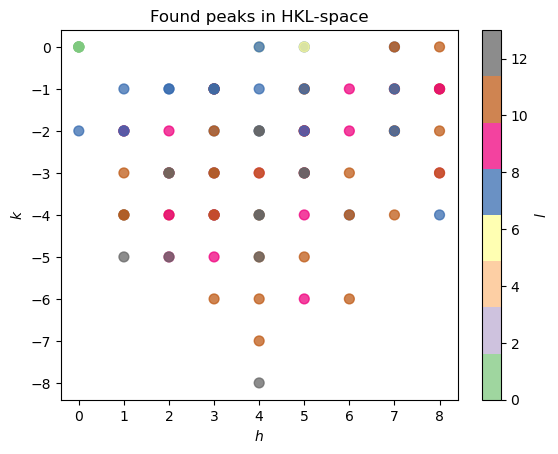

In [58]:
np_hkl = numpy.stack([
    numpy.array(mtd["strong_peaks"].column('h'), dtype=float),
    numpy.array(mtd["strong_peaks"].column('k'), dtype=float),
    numpy.array(mtd["strong_peaks"].column('l'), dtype=float)], axis=0)
print(np_hkl)
plt.scatter(np_hkl[0], np_hkl[1], c=np_hkl[2], alpha=0.75, s=50, cmap='Accent')
cbar = plt.colorbar()
cbar.set_label(r'$l$')
plt.xlabel(r'$h$')
plt.ylabel(r'$k$')
plt.title('Found peaks in HKL-space')

Text(0.5, 1.0, 'Found peaks in HKL-space')

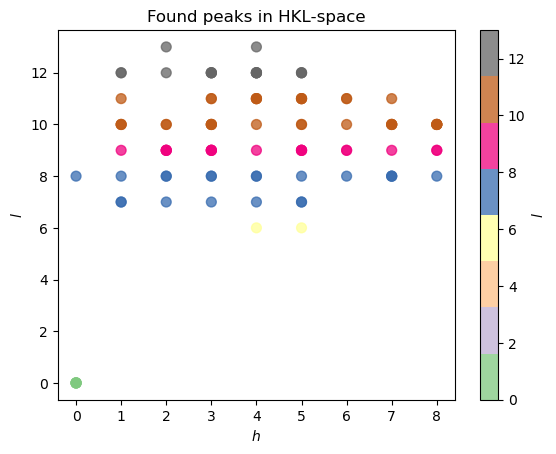

In [59]:
plt.scatter(np_hkl[0], np_hkl[2], c=np_hkl[2], alpha=0.75, s=50, cmap='Accent')
cbar = plt.colorbar()
cbar.set_label(r'$l$')
plt.xlabel(r'$h$')
plt.ylabel(r'$l$')
plt.title('Found peaks in HKL-space')

# Normalization per monitor

In [60]:
ws_norm


Workspace2D
Title: tof_egs2_1.plot
Histograms: 1
Bins: 101
Data points
X axis: Time_of_flight___gms_ / 
Y axis: Intensity
Distribution: False
Instrument: None
Run start: not available
Run end:  not available

In [70]:
ws_tof

Workspace2D
Title: tof_egs2_1.plot
Histograms: 1
Bins: 101
Data points
X axis: Time_of_flight___gms_ / 
Y axis: Intensity
Distribution: False
Instrument: None
Run start: not available
Run end:  not available

In [71]:
from mantid.simpleapi import ConvertUnits
ws_tof = mtd['tof_egs2_1.plot_mcstas_data']
ws_tof.getAxis(0).setUnit("TOF")
ws_lambda = ConvertUnits(
    InputWorkspace=ws_tof,
    Target="Wavelength"
)
ws_lambda

ConvertUnits-[Notice] ConvertUnits started
ConvertUnits-[Error] Error in execution of algorithm ConvertUnits:
ConvertUnits-[Error] Source component has not been specified


RuntimeError: ConvertUnits-v1: Source component has not been specified

In [86]:
import numpy as np
from mantid.simpleapi import CreateWorkspace

ws_tof = mtd["tof_egs2_1.plot_mcstas_data"]  # your monitor
L1 = 146  # meters – put your real source→monitor distance here

# TOF axis (bin edges)
tof = ws_tof.readX(0)  # shape (N+1,)

# convert µs → Å
lambda_axis = 3.956034 * tof / (1000.0 * L1)

# copy Y and E
y = ws_tof.readY(0)
e = ws_tof.readE(0)

ws_lambda = CreateWorkspace(
    DataX=lambda_axis,
    DataY=y,
    DataE=e,
    NSpec=1,
    UnitX="Wavelength"
)


CreateWorkspace-[Notice] CreateWorkspace started
CreateWorkspace-[Notice] CreateWorkspace successful, Duration 0.00 seconds


In [87]:
# Normalization
l_monitor_wavelength = ws_lambda.readX(0)
l_monitor_intensity = ws_lambda.readY(0)
func_spectra = scipy.interpolate.interp1d(l_monitor_wavelength, l_monitor_intensity)

In [88]:
l_monitor_wavelength

array([0.01877949, 0.05633847, 0.09389746, 0.13145644, 0.16901542,
       0.20657441, 0.24413339, 0.28169237, 0.31925135, 0.35681034,
       0.39436932, 0.4319283 , 0.46948728, 0.50704627, 0.54460525,
       0.58216423, 0.61972322, 0.6572822 , 0.69484118, 0.73240016,
       0.76995915, 0.80751813, 0.84507711, 0.8826361 , 0.92019508,
       0.95775406, 0.99531304, 1.03287203, 1.07043101, 1.10798999,
       1.14554897, 1.18310796, 1.22066694, 1.25822592, 1.29578491,
       1.33334389, 1.37090287, 1.40846185, 1.44602084, 1.48357982,
       1.5211388 , 1.55869779, 1.59625677, 1.63381575, 1.67137473,
       1.70893372, 1.7464927 , 1.78405168, 1.82161066, 1.85916965,
       1.89672863, 1.93428761, 1.9718466 , 2.00940558, 2.04696456,
       2.08452354, 2.12208253, 2.15964151, 2.19720049, 2.23475948,
       2.27231846, 2.30987744, 2.34743642, 2.38499541, 2.42255439,
       2.46011337, 2.49767235, 2.53523134, 2.57279032, 2.6103493 ,
       2.64790829, 2.68546727, 2.72302625, 2.76058523, 2.79814

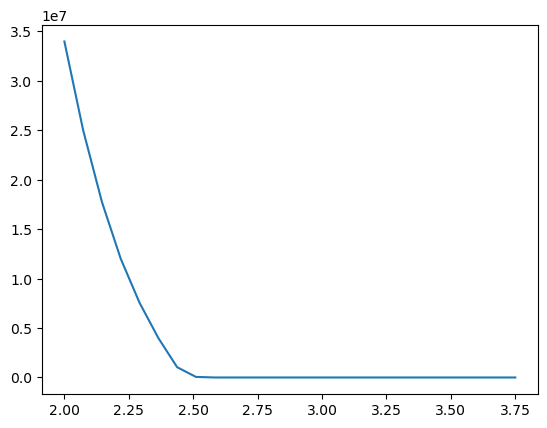

In [89]:
np_lambda = numpy.linspace(2., 3.75, num = 25, endpoint=True)
plt.plot(np_lambda, func_spectra(np_lambda))

In [63]:
def write_to_file(peaks_workspace_name: str, file_out:str):
    peaks_workspace = mtd[peaks_workspace_name]
    np_h = numpy.array(peaks_workspace.column('h'), dtype=float)
    np_k = numpy.array(peaks_workspace.column('k'), dtype=float)
    np_l = numpy.array(peaks_workspace.column('l'), dtype=float)
    np_int = numpy.array(peaks_workspace.column("Intens"), dtype=float)
    np_sint = numpy.array(peaks_workspace.column("SigInt"), dtype=float)
    np_wavelength = numpy.array(peaks_workspace.column("Wavelength"), dtype=float)
    np_d = numpy.array(peaks_workspace.column("DSpacing"), dtype=float)

    np_tth = 2 * numpy.asin(0.5 * np_wavelength / np_d)
    
    # f_name_hkl = "C60_tetra.hkl"
    f_name_hkl = "peaks_scipp.hkl"
    np_hkl_model, np_fsq_model = load_fsq(f_name_hkl)

    np_hkl_order = numpy.square(np_h) + numpy.square(np_k) + numpy.square(np_l)
    np_arg = numpy.argsort(np_hkl_order) 
    ls_out = ["""loop_
_diffrn_refln_index_h
_diffrn_refln_index_k
_diffrn_refln_index_l
_diffrn_refln_intensity
_diffrn_refln_intensity_sigma
_diffrn_refln_fsq_model
_diffrn_refln_intensity_no_norm
_diffrn_refln_intensity_sigma_no_norm
_diffrn_refln_intensity_incident
_diffrn_refln_wavelength
_diffrn_refln_ttheta
_diffrn_refln_d"""]
    flag_normalize_per_wavelength = True
    flag_normalize_per_sin_sq_th = True
    for i in np_arg:
        h, k, l = int(numpy.round(np_h[i], 0)), int(numpy.round(np_k[i], 0)), int(numpy.round(np_l[i], 0))
        flag_model = numpy.logical_and(np_hkl_model[0] == h, numpy.logical_and(np_hkl_model[1] == k, np_hkl_model[2] == l))
        try:
            fsq_model = np_fsq_model[flag_model][0]
        except:
            fsq_model = 9999
        if numpy.isclose(numpy.square(h)+numpy.square(k)+numpy.square(l), 0):
            continue
        iint, siint = np_int[i], np_sint[i]
        wavelength = np_wavelength[i]
        tth = numpy.degrees(np_tth[i])
        d = np_d[i]
        incident = func_spectra(wavelength)
        if wavelength < 2.25 or wavelength > 3.5 :
            continue
        iint_n = iint *  1e8/incident
        siint_n = siint * 1e8/incident

        if flag_normalize_per_wavelength:
            iint_n = iint_n / numpy.power(wavelength, 4)
            siint_n = siint_n / numpy.power(wavelength, 4)
        if flag_normalize_per_sin_sq_th:
            iint_n = 1 * iint_n * (numpy.sin(0.5*numpy.radians(tth)))**2
            siint_n = 1 * siint_n * (numpy.sin(0.5*numpy.radians(tth)))**2
        s_out = f"{h:5.0f} {k:5.0f} {l:5.0f} {iint_n:9.0f} {siint_n:9.0f} {fsq_model:9.0f} {iint:9.2f} {siint:9.2f} {incident:9.0f} {wavelength:7.5f} {tth:7.2f} {d:7.5f}" 
        ls_out.append(s_out)
    with open(file_out,'w') as fid:
        fid.write("\n".join(ls_out))
    return

In [64]:

def load_fsq(f_name:str):
    with open(f_name, 'r') as fid:
        l_content = fid.readlines()
    l_content = [hh for hh in l_content if not hh.startswith("#")]
    l_hkl, l_fsq = [], []
    for line in l_content:
        l_hh = line.strip().split()
        l_hkl.append((int(l_hh[0]), int(l_hh[1]), int(l_hh[2])))
        # l_fsq.append(l_hh[-1])
        l_fsq.append(l_hh[3])
    np_hkl = numpy.array(l_hkl, dtype=int).transpose()
    np_fsq = numpy.array(l_fsq, dtype = float)
    return np_hkl, np_fsq


In [65]:
write_to_file("integrated_strong_peaks", 'peaks.hkl')

In [ ]:

# %%
hkl = -3, 3, 3
flag_hkl = numpy.logical_and(np_hkl[0] == hkl[0],
numpy.logical_and(np_hkl[1] == hkl[1], np_hkl[2] == hkl[2]))
np_fsq[flag_hkl]
# %%

# %%

f_name_hkl = "C60_tetra.hkl"
np_hkl, np_fsq = load_fsq(f_name_hkl)
# %%

print(print_table("integrated_strong_peaks"))

# %%

print(print_table("strong_peaks"))


# %%
mtd['strong_peaks'].columnCount()

mtd['strong_peaks'].getTitle()
mtd['strong_peaks'].getNumberPeaks()
mtd['strong_peaks'].getName()
mtd['strong_peaks'].getColumnNames()
mtd['strong_peaks'].column('DSpacing')
mtd['strong_peaks'].column('TOF')
mtd['strong_peaks'].column('Wavelength')
# %%



FindUBUsingFFT(PeaksWorkspace='strong_peaks',MinD='0.5',MaxD='16')
print(mtd["strong_peaks"].sample().hasOrientedLattice())
print(mtd["strong_peaks"].sample().getOrientedLattice().getUB())# %%
# # %% Find UB-matrix by FFT
# tol = 0.2
# FindUBUsingFFT(PeaksWorkspace="strong_peaks", MinD=1, MaxD=10, Tolerance=tol)
# print(mtd["strong_peaks"].sample().hasOrientedLattice())
# print(mtd["strong_peaks"].sample().getOrientedLattice().getUB())# %%
# %% Index peaks by found UB-matrix

# PeakRadius=0.12, BackgroundOuterRadius=0.2, BackgroundInnerRadius=0.16,)



# %%
 


# %%
mtd['integrated_strong_peaks'].getColumnNames()

# %%
mtd['integrated_strong_peaks'].column('Intens') = 0.01*mtd['integrated_strong_peaks'].column('Intens')
# %%
mtd['integrated_strong_peaks'].column('Intens') = 0.01*mtd['integrated_strong_peaks'].column('Intens')

# %%
mtd['integrated_strong_peaks'].column('SigInt')
# %%
dir(mtd['integrated_strong_peaks'])

# %%

SaveHKL(InputWorkspace="integrated_strong_peaks", Filename="peaks.hkl")
# %%
CopySample(InputWorkspace="integrated_strong_peaks", OutputWorkspace="strong_peaks")
# %%

ConvertToDiffractionMDWorkspace(
    InputWorkspace='EventData_mcstas_data', 
    OutputWorkspace='md_space',
    OutputDimensions="HKL")


# %%
mtd["strong_peaks"]
# %%
mtd["sample"]

# %%
help(FindUBUsingLatticeParameters)
# %%


# %%
mtd["integrated_strong_peaks"]
# %%

print(mtd.getObjectNames())
# %%



# %%

# %%

# %%

mtd["mcstas_data"]
# %% Look on the data

mtd["EventData_mcstas_data"]
# %% Look on the data
mtd["EventData_mcstas_data"].getNumberEvents()
# %% 
mtd["EventData_mcstas_data"].getTofMax()
# %% 
mtd["EventData_mcstas_data"].getTofMin()
# %% 
plotSpectrum("EventData_mcstas_data",[0,])
# %% 
mtd["EventData_mcstas_data"].getEventList(39999)
# %% 

mtd["EventData_mcstas_data"].getNumberHistograms()
# %% 
evList = mtd["EventData_mcstas_data"].getSpectrum(39999)
# %% 
Rebin("EventData_mcstas_data", "BinnedData")
# %% Get some basic information
print("Number of events in event List 0: {}".format(evList.getNumberEvents()))
print("Minimum time of flight in event List 0: {}".format(evList.getTofMax()))
print("Maximum time of flight in event List 0: {}".format(evList.getTofMax()))
print("Memory used: {}".format(evList.getMemorySize()))
print("Type of Events: {}".format(evList.getEventType()))

# %% 
mtd["EventData_mcstas_data"]